In [1]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

In [2]:
f_cc = h5py.File('test_merger.h5', 'r')
f_nc = h5py.File('test_merger_NC.h5', 'r')

In [3]:
f_nc.keys()

<KeysViewHDF5 ['Azimuth', 'Beta1', 'Beta1Reco', 'Beta2', 'Beta2Reco', 'Beta3', 'Beta3Reco', 'Beta4', 'Beta4Reco', 'Beta5', 'Beta5Reco', 'CogX', 'CogY', 'CogZ', 'EventCounter', 'Inelasticity', 'OMMapReco', 'OMMapTrue', 'PrimaryEnergy', 'RecoDirX', 'RecoDirY', 'RecoDirZ', 'RecoEnergy', 'RecoVertexTime', 'RecoX', 'RecoY', 'RecoZ', 'SecondaryEnergy', 'TotalCharge', 'TotalmDOMCharge', 'TrueTime', 'TrueX', 'TrueY', 'TrueZ', 'Zenith', 'filename']>

In [8]:
f_nc['EventCounter']['value']

array([2.00008363e+10, 2.00008363e+10, 2.00008363e+10, ...,
       2.00017441e+10, 2.00017441e+10, 2.00017441e+10])

In [9]:
f_nc['EventCounter']['value'] - f_nc['EventCounter']['value']

array([0., 0., 0., ..., 0., 0., 0.])

In [10]:
f_cc['PrimaryEnergy'][:]

array([(121629,   60, 0, 0, 1,  6.4039891 ),
       (121629,   85, 0, 0, 1,  7.12170293),
       (121629,  101, 0, 0, 1,  1.15478094), ...,
       (120028, 2956, 0, 0, 1, 18.16887785),
       (120028, 2968, 0, 0, 1, 12.60609427),
       (120028, 3059, 0, 0, 1, 21.00252321)],
      dtype={'names': ['Run', 'Event', 'SubEvent', 'SubEventStream', 'exists', 'value'], 'formats': ['<u4', '<u4', '<u4', '<i4', 'u1', '<f8'], 'offsets': [0, 4, 8, 12, 16, 24], 'itemsize': 32})

In [14]:
f_nc['EventCounter']['value'][f_nc['PrimaryEnergy']['value']<60]

array([2.00008363e+10, 2.00008363e+10, 2.00008363e+10, ...,
       2.00017441e+10, 2.00017441e+10, 2.00017441e+10])

In [70]:
f_cc['PrimaryEnergy']['Run'][f_cc['PrimaryEnergy']['Event']==60]

array([121629, 121629, 120028, 120028, 120028, 120028, 120028, 120028,
       120028, 120028, 120028, 120028, 120028, 120028, 120028, 120028,
       120028], dtype=uint32)

In [72]:
f_cc['PrimaryEnergy']['value'][f_cc['PrimaryEnergy']['Event']==60]

array([ 6.4039891 ,  4.71393128, 23.58695332,  6.51064338, 16.54274084,
        5.74749433,  9.36579328,  6.28109312, 11.5681974 ,  6.98595579,
        6.30028903, 25.39245941, 72.25892288, 19.80353472, 31.72394336,
        1.21348541, 11.1299486 ])

In [73]:
f_cc['PrimaryEnergy']['SubEvent'][f_cc['PrimaryEnergy']['Event']==60]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0], dtype=uint32)

In [17]:
f_nc['OMMapTrue']['om_counter']

array([2.00008363e+10, 2.00008363e+10, 2.00008363e+10, ...,
       2.00017441e+10, 2.00017441e+10, 2.00017441e+10])

In [86]:
#### First make event level cuts ######
# cuts on energy
# cuts on inelasticity, only for CC
# cuts on vertex

#run = f_cc['PrimaryEnergy']['Run']
#event = f_cc['PrimaryEnergy']['Event']

event_counter = f_nc['EventCounter']['value']
om_counter = f_nc['OMMapTrue']['om_counter']

#om_run = f_cc['OMMapTrue']['Run']
#om_event = f_cc['OMMapTrue']['Event']

energy = f_nc['PrimaryEnergy']['value']
inelasticity = f_nc['Inelasticity']['value']

#trueX = f_cc['TrueX']['value']
#trueY = f_cc['TrueY']['value']
#trueZ = f_cc['TrueZ']['value']

emin, emax = 10, 100

imin, imax = 0, 1

energy_boolean = (energy > emin) & (energy <= emax)
#inelasticity_boolean = (inelasticity > imin) & (inelasticity <= imax)

event_boolean = energy_boolean #& inelasticity_boolean

select_event_counter = event_counter[event_boolean]
#select_run = run[event_boolean]
#select_event = event[event_boolean]

In [87]:
# Apply the cuts
filtered_data = {}

# Loop through all keys (datasets) and apply the cut
for key in f_nc.keys():
    data = f_nc[key][:]
    if key == 'OMMapReco' or key == 'OMMapTrue':
        #om_event_condition = np.where(np.isin(om_event, select_event))[0]
        #om_run_condition = np.where(np.isin(om_run, select_run))[0]
        om_event_condition = np.where(np.isin(om_counter, select_event_counter))[0]
        #om_index = np.intersect1d(om_event_condition, om_run_condition)
        #print(om_index)
        #filtered_data[key] = data[om_index]
        print(om_event_condition)
        filtered_data[key] = data[om_event_condition]
        continue
    else:
        filtered_data[key] = data[event_boolean]  # This applies the condition to each dataset

[     28      29      30 ... 4198090 4198091 4198092]
[     28      29      30 ... 4198090 4198091 4198092]


In [88]:
filtered_data['OMMapReco'][:]

array([(120029,  623, 0, 0, 1,  0, 1.45033166, 275.02363575, 1.14618874, 10354.64883888, 59.23692353, -52.08227557, -35.18249849, 2.00008363e+10, 26.9048764, -31.316284 , -346.8685269,  38.95778602),
       (120029,  623, 0, 0, 1,  1, 2.0970876 , 207.50196101, 0.96928477, 10604.25170938, 23.39343293, -48.18301897, -98.18249849, 2.00008363e+10, 62.748367 , -35.2155406, -283.8685269, 173.30782447),
       (120029,  623, 0, 0, 1,  2, 1.15662866, 300.46924302, 1.17001712, 10069.00806827, -3.19999067, -24.27477557,   0.81750151, 2.00008363e+10, 89.3417906, -59.123784 , -382.8685269,  33.23002309),
       ...,
       (120029, 9324, 0, 0, 1, 19, 1.23849294, 330.61581061, 1.13468826, 10737.40881577, 12.9394445 ,  -4.32125948,  15.04760607, 2.00017441e+10, 18.29     , -51.1298361, -385.785338 ,  14.63503538),
       (120029, 9324, 0, 0, 1, 20, 1.06730795, 381.66189285, 0.94679058, 11203.74716977, 12.8876539 ,  -4.52237958,  66.13079497, 2.00017441e+10, 18.3417906, -50.928716 , -436.8685269, 267

Text(0.5, 1.0, 'Energy 10 - 100')

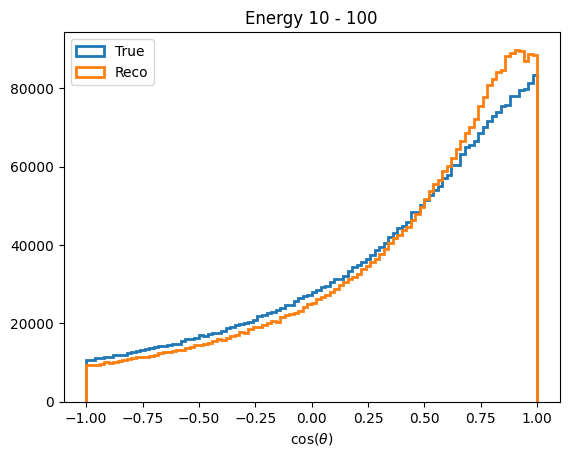

In [89]:
plt.hist(np.cos(filtered_data['OMMapTrue']['angle']), bins=100, histtype='step', lw = 2, label='True')
plt.hist(-np.cos(filtered_data['OMMapReco']['angle_reco']), bins=100, histtype='step', lw = 2, label='Reco')
plt.legend()
plt.xlabel(r'$\cos (\theta)$')
plt.title('Energy {} - {}'.format(emin, emax))

Text(0.5, 1.0, 'Energy 10 - 100')

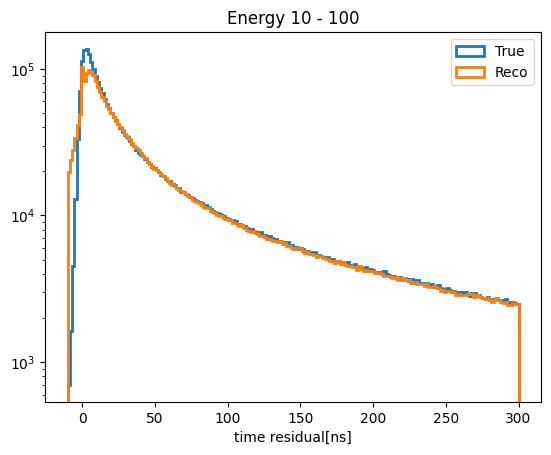

In [91]:
min_val = -10 #-90
max_val = 300 #600

tRes_true = filtered_data['OMMapTrue']['time_residual']
tRes_reco = filtered_data['OMMapReco']['time_residual_reco']

tres_true_bool = (tRes_true>=min_val)&(tRes_true<=max_val)
tres_reco_bool = (tRes_reco>=min_val)&(tRes_reco<=max_val)

plt.hist(tRes_true[tres_true_bool], bins=200, log=True, histtype='step', lw = 2, label='True')
plt.hist(tRes_reco[tres_reco_bool], bins=200, log=True, histtype='step', lw = 2, label='Reco')
plt.legend()
plt.xlabel('time residual[ns]')
plt.title('Energy {} - {}'.format(emin, emax))

Text(0, 0.5, 'Reco Time')

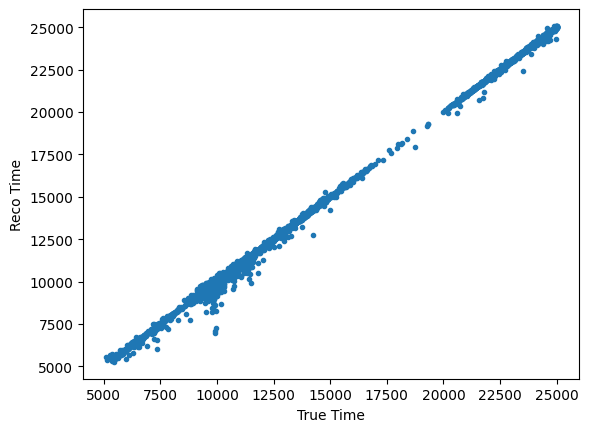

In [93]:
plt.plot(filtered_data['TrueTime']['value'], filtered_data['RecoVertexTime']['value'], '.')
plt.xlabel('True Time')
plt.ylabel('Reco Time')

In [41]:
len(filtered_data['OMMapTrue']['angle']), len(filtered_data['OMMapReco']['angle_reco'])

(862874, 862874)

In [21]:
len(filtered_data['OMMapTrue']['time_residual'])

862874

In [22]:
len(f_cc['OMMapTrue']['time_residual'])

4711397

In [48]:
len(filtered_data['Azimuth']['value'])

11218

In [ ]:
def constraint(value, run, event, min_val, max_val):
    value = value
    boolean = (enegy_value > min_val) & (energy_value <= max_val)
    run = run[boolean]
    event = run[boolean]

        if dataset == 'NC':
            energy_value = value
            boolean = (enegy_value > min_val) & (energy_value <= max_val)
            run = run[boolean]
            event = run[boolean]

    if constraint_type == 'inelasticity':
        if dataset == 'NC':
            value = 

        

In [3]:
primary_energy_value = f_cc['PrimaryEnergy']['value']
primary_energy_run = f_cc['PrimaryEnergy']['Run']
primary_energy_event = f_cc['PrimaryEnergy']['Event']

In [4]:
len(primary_energy_value)

86254

In [9]:
boolean = (primary_energy_value > 40) & (primary_energy_value <= 50)
select_energy_value = primary_energy_value[boolean]
select_energy_run = primary_energy_run[boolean]
select_energy_event = primary_energy_event[boolean]

In [32]:
select_energy_event.max()

31234

In [16]:
time_residual_value = f_cc['OMMapTrue']['time_residual']
om_run = f_cc['OMMapTrue']['Run']
om_event = f_cc['OMMapTrue']['Event']

In [42]:
select_energy_event

array([ 645, 5207, 9063, ..., 2664,  516, 1592], dtype=uint32)

In [22]:
om_event[om_event in select_energy_event]

/tmp/ipykernel_3781/1726649.py:1: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.
  om_event[om_event in select_energy_event]


array([], shape=(0, 4711397), dtype=uint32)

In [25]:
ind_result = np.where(np.isin(om_event, select_energy_event))[0]

In [34]:
np.where(np.isin(om_event, select_energy_event))

(array([    127,     128,     129, ..., 4711238, 4711395, 4711396]),)

In [33]:
om_event[ind_result].max()

31234

In [34]:
# using numpy.isin() method 
gfg1 = np.array([1, 2, 3, 4, 5, 5, 5, 5, 3, 3, 1, 1, 3, 4, 2, 4, 4, 5, 2, 3]) 
lis = [1, 3, 5] 
lis1 = [3, 4, 6, 7, 8, 9]
gfg_ind1 = np.where(np.isin(gfg1, lis))[0]
gfg_ind2 = np.where(np.isin(gfg1, lis1))[0]

intersec_index = np.intersect1d(gfg_ind1, gfg_ind2)
  
print(gfg_ind1)
print(gfg_ind2)
print(intersec_index)

[ 0  2  4  5  6  7  8  9 10 11 12 17 19]
[ 2  3  8  9 12 13 15 16 19]
[ 2  8  9 12 19]


In [33]:
np.where(np.isin(gfg1, lis))

(array([ 0,  2,  4,  5,  6,  7,  8,  9, 10, 11, 12, 17, 19]),)

In [39]:
# using numpy.isin() method 
gfg1 = np.array([1, 2, 3, 4, 5, 5, 5, 5, 3, 3, 1, 1, 3, 4, 2, 4, 4, 5, 2, 3]) 
lis = [1, 9, 9, 6, 7, 7, 4, 5] 
gfg = np.where(np.isin(lis, gfg1))
  
print(gfg)

(array([0, 6, 7]),)


In [21]:
lenom_event[select_energy_event]

3104

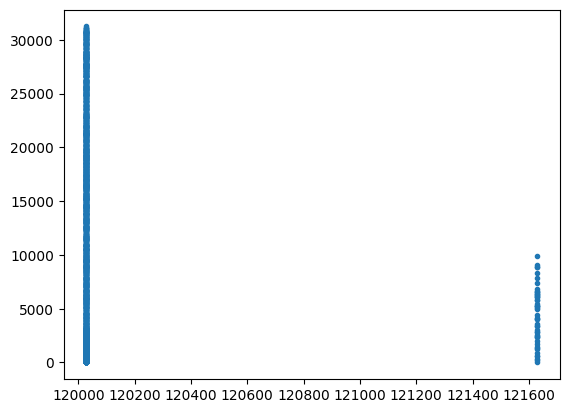

In [11]:
plt.plot(select_energy_run, select_energy_event, '.')

In [14]:
f_cc['OMMapTrue'].dtype

dtype({'names': ['Run', 'Event', 'SubEvent', 'SubEventStream', 'exists', 'vector_index', 'angle', 'distance', 'hit_charge', 'hit_time', 'hx', 'hy', 'hz', 'ox', 'oy', 'oz', 'time_residual'], 'formats': ['<u4', '<u4', '<u4', '<i4', 'u1', '<u8', '<f8', '<f8', '<f8', '<f8', '<f8', '<f8', '<f8', '<f8', '<f8', '<f8', '<f8'], 'offsets': [0, 4, 8, 12, 16, 24, 32, 40, 48, 56, 64, 72, 80, 88, 96, 104, 112], 'itemsize': 128})

(array([2659393.,  248003.,  252859.,  231236.,  235162.,  217738.,
         233433.,  224130.,  220339.,  189104.]),
 array([    0. ,  3154.9,  6309.8,  9464.7, 12619.6, 15774.5, 18929.4,
        22084.3, 25239.2, 28394.1, 31549. ]),
 <BarContainer object of 10 artists>)

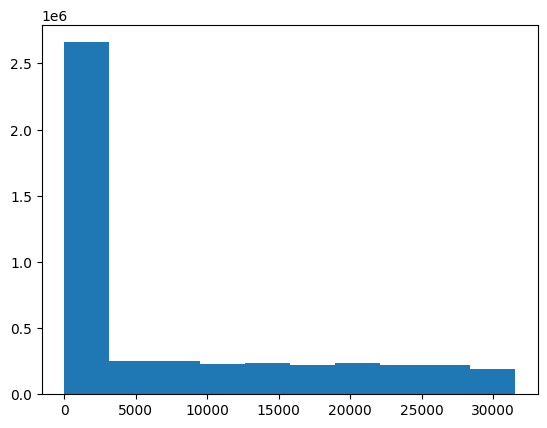

In [65]:
plt.hist(f_cc['OMMapTrue']['Event'])

In [41]:
time_residual = f_cc['OMMapTrue'][energy>50]['time_residual']
energy = f_cc['PrimaryEnergy']['value']

TypeError: Boolean indexing array has incompatible shape

In [39]:
len(time_residual)

4711397

(array([7527., 6934., 5098., 2669., 1810., 1452., 1132.,  792.,  677.,
         609.]),
 array([ 1.00285137, 10.90247046, 20.80208956, 30.70170865, 40.60132775,
        50.50094685, 60.40056594, 70.30018504, 80.19980413, 90.09942323,
        99.99904233]),
 <BarContainer object of 10 artists>)

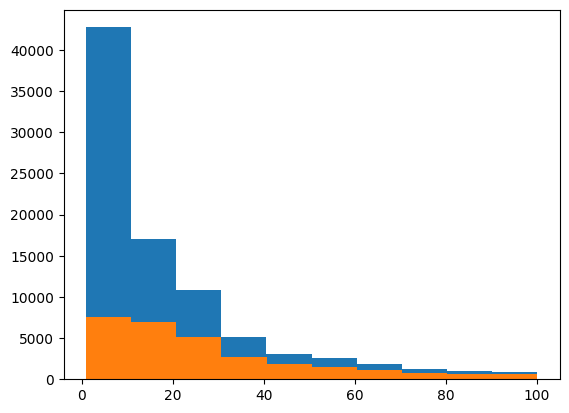

In [30]:
plt.hist(f_cc['PrimaryEnergy']['value'])
plt.hist(f_nc['PrimaryEnergy']['value'])

In [28]:
f_cc['Azimuth']['value']

array([1.93385347, 3.38517736, 3.56274397, ..., 5.74224701, 4.6880393 ,
       4.33868542])

In [47]:
# Open the HDF5 file
with h5py.File('test_merger.h5', 'r') as file:
    # Load the PrimaryEnergy and OMMapTrue arrays
    primary_energy_data = file['PrimaryEnergy'][:]  # Energy array
    om_map_true_data = file['OMMapTrue'][:]  # OMMapTrue array
    
    # Specify the target energy value you're interested in
    target_energy = 100  # Replace with the specific energy value
    
    # Find the indices where PrimaryEnergy matches the target energy
    matching_indices = np.where(primary_energy_data == target_energy)[0]
    
    # Get the corresponding OMMapTrue values
    matching_om_map_true = om_map_true_data[matching_indices]
    
    # Print or process the corresponding OMMapTrue values
    print(f"OMMapTrue values for energy {target_energy}: {matching_om_map_true}")

TypeError: Cannot compare structured or void to non-void arrays.

In [53]:
# Open the HDF5 file
with h5py.File('test_merger.h5', 'r') as file:
    # Load the PrimaryEnergy and OMMapTrue arrays
    primary_energy_data = file['PrimaryEnergy']
    om_map_true_data = file['OMMapTrue'][:]  # OMMapTrue array
    
    # Check the data type of PrimaryEnergy to ensure it's what we expect
    print(f"PrimaryEnergy data type: {primary_energy_data.dtype}")
    
    # If it's a structured array, print the fields to see the structure
    if primary_energy_data.dtype.names:
        print("Fields in PrimaryEnergy:", primary_energy_data.dtype.names)
    
    # Assume PrimaryEnergy is a simple array, extract it if needed
    if primary_energy_data.dtype.names:
        # If PrimaryEnergy is structured, access the relevant field
        primary_energy_data = primary_energy_data['value']  # Replace with actual field name
        print(f"Extracted energy values: {primary_energy_data[:5]}")  # Example to print first 5 values
    
    # Specify the target energy value you're interested in
    target_energy = 100  # Replace with the specific energy value
    
    # Find the indices where PrimaryEnergy matches the target energy
    matching_indices = np.where(primary_energy_data < 100)[0]
    
    # Get the corresponding OMMapTrue values
    matching_om_map_true = om_map_true_data[matching_indices]
    print(len(om_map_true_data), len(om_map_true_data[matching_indices]))
    
    # Print or process the corresponding OMMapTrue values
    print(f"OMMapTrue values for energy {target_energy}: {matching_om_map_true}")

PrimaryEnergy data type: {'names': ['Run', 'Event', 'SubEvent', 'SubEventStream', 'exists', 'value'], 'formats': ['<u4', '<u4', '<u4', '<i4', 'u1', '<f8'], 'offsets': [0, 4, 8, 12, 16, 24], 'itemsize': 32}
Fields in PrimaryEnergy: ('Run', 'Event', 'SubEvent', 'SubEventStream', 'exists', 'value')
Extracted energy values: [6.4039891  7.12170293 1.15478094 6.98685674 3.03380289]
4711397 86254
OMMapTrue values for energy 100: [(121629,   60, 0, 0, 1,   0, 1.70105348, 269.133685  , 1.18535745, 11078.54084075, -24.02375843, -45.57191779,  63.24042067, 26.831633 , -31.1394594, -340.8685269, 760.08523884)
 (121629,   60, 0, 0, 1,   1, 1.63567722, 245.18788302, 0.95275819, 10404.39977032, -59.76366783, -41.42259319,  33.24042067, 62.5715424, -35.288784 , -310.8685269,  93.25037824)
 (121629,   60, 0, 0, 1,   2, 1.25031362, 275.59972669, 0.89016247, 10580.07097197, -86.48212543, -17.78871329,  60.15723177, 89.29     , -58.9226639, -337.785338 , 147.28316407)
 ...
 (121629, 6842, 0, 0, 1, 393, 1.

In [60]:
# Open the HDF5 file
with h5py.File('test_merger.h5', 'r') as file:
    # Load the PrimaryEnergy and OMMapTrue arrays
    primary_energy_data = file['PrimaryEnergy'][:]
    om_map_true_data = file['OMMapTrue'][:]  # OMMapTrue array

    print(primary_energy_data, om_map_true_data)

[(121629,   60, 0, 0, 1,  6.4039891 ) (121629,   85, 0, 0, 1,  7.12170293)
 (121629,  101, 0, 0, 1,  1.15478094) ...
 (120028, 2956, 0, 0, 1, 18.16887785) (120028, 2968, 0, 0, 1, 12.60609427)
 (120028, 3059, 0, 0, 1, 21.00252321)] [(121629,   60, 0, 0, 1,  0, 1.70105348, 269.133685  , 1.18535745, 11078.54084075, -24.02375843, -45.57191779, 63.24042067, 26.831633 , -31.1394594, -340.8685269, 760.08523884)
 (121629,   60, 0, 0, 1,  1, 1.63567722, 245.18788302, 0.95275819, 10404.39977032, -59.76366783, -41.42259319, 33.24042067, 62.5715424, -35.288784 , -310.8685269,  93.25037824)
 (121629,   60, 0, 0, 1,  2, 1.25031362, 275.59972669, 0.89016247, 10580.07097197, -86.48212543, -17.78871329, 60.15723177, 89.29     , -58.9226639, -337.785338 , 147.28316407)
 ...
 (120028, 2968, 0, 0, 1, 19, 0.43752611, 214.94391868, 0.77217358, 11093.57396133, -25.32649002,  18.42804029, 80.14920425, 14.3660861, -80.56375  , -274.785338 , 900.40711389)
 (120028, 3059, 0, 0, 1,  0, 2.43098518, 274.20234934, 0

ValueError: Invalid dataset identifier (invalid dataset identifier)